In [20]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/praneetharamagiri/diabetics/Dabetics-dataset.csv


In [21]:
import pandas as pd
import numpy as np

file_path = "/kaggle/input/datasets/praneetharamagiri/diabetics/Dabetics-dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [22]:
df.head()

,Unnamed: 0,Visit_ID,Social Life,BP,Age,Sex,Chol,Trig,HDL,LDL,VLDL,Fiamly \n1)father\n2) mather \n3)uncle(mother's side)\n4)uncle(father's side),HbA1c,BMI,RBS,FBS
0,1,24002367,city,12.0/8.0,51Years,FEMALE,174,92,35.0,125.0,18.0,0,4.9,34.3,94.0,NaN
1,2,24002365,city,11.0/7.5,42Years,MALE,153,72,34.0,105.0,14.0,0,5.1,28.2,105.0,NaN
2,3,24002356,city,12.0/8.0,34Years,FEMALE,144,99,36.0,108.0,19.0,2-4,5.0,23.03,NaN,97.0
3,4,24002401,city,12.0/9.0,53Years,MALE,159,297,27.0,99.0,59.0,1-2-3,6.7,20.8,145.5,NaN
4,5,24002401,city,11.0/7.5,37Years,MALE,262,234,30.0,192.0,47.0,0,5.2,29.7,93.0,NaN


In [23]:
df.shape

(662, 16)

In [24]:
print(df.columns.tolist())

['Unnamed: 0', 'Visit_ID', 'Social Life', 'BP', 'Age', 'Sex', 'Chol', 'Trig', 'HDL', 'LDL', 'VLDL', "Fiamly \n1)father\n2) mather \n3)uncle(mother's side)\n4)uncle(father's side) ", 'HbA1c', 'BMI', 'RBS', 'FBS']


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 16 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Unnamed: 0                                                                  662 non-null    int64  
 1   Visit_ID                                                                    662 non-null    int64  
 2   Social Life                                                                 662 non-null    object 
 3   BP                                                                          660 non-null    object 
 4   Age                                                                         662 non-null    object 
 5   Sex                                                                         662 non-null    object 
 6   Chol                                              

In [26]:
df.isnull().sum()

Unnamed: 0                                                                          0
Visit_ID                                                                            0
Social Life                                                                         0
BP                                                                                  2
Age                                                                                 0
Sex                                                                                 0
Chol                                                                                0
Trig                                                                                0
HDL                                                                                 3
LDL                                                                                 3
VLDL                                                                                3
Fiamly \n1)father\n2) mather \n3)uncle(mother's side)\

In [27]:
df.columns = df.columns.str.strip()

df.columns = [
    "Unnamed",
    "Visit_ID",
    "Social_Life",
    "BP",
    "Age",
    "Sex",
    "Chol",
    "Trig",
    "HDL",
    "LDL",
    "VLDL",
    "Family_History",
    "HbA1c",
    "BMI",
    "RBS",
    "FBS"
]

df.head()

,Unnamed,Visit_ID,Social_Life,BP,Age,Sex,Chol,Trig,HDL,LDL,VLDL,Family_History,HbA1c,BMI,RBS,FBS
0,1,24002367,city,12.0/8.0,51Years,FEMALE,174,92,35.0,125.0,18.0,0,4.9,34.3,94.0,NaN
1,2,24002365,city,11.0/7.5,42Years,MALE,153,72,34.0,105.0,14.0,0,5.1,28.2,105.0,NaN
2,3,24002356,city,12.0/8.0,34Years,FEMALE,144,99,36.0,108.0,19.0,2-4,5.0,23.03,NaN,97.0
3,4,24002401,city,12.0/9.0,53Years,MALE,159,297,27.0,99.0,59.0,1-2-3,6.7,20.8,145.5,NaN
4,5,24002401,city,11.0/7.5,37Years,MALE,262,234,30.0,192.0,47.0,0,5.2,29.7,93.0,NaN


In [28]:
df.drop(columns=["Unnamed", "Visit_ID", "FBS"], inplace=True)

df.head()

,Social_Life,BP,Age,Sex,Chol,Trig,HDL,LDL,VLDL,Family_History,HbA1c,BMI,RBS
0,city,12.0/8.0,51Years,FEMALE,174,92,35.0,125.0,18.0,0,4.9,34.3,94.0
1,city,11.0/7.5,42Years,MALE,153,72,34.0,105.0,14.0,0,5.1,28.2,105.0
2,city,12.0/8.0,34Years,FEMALE,144,99,36.0,108.0,19.0,2-4,5.0,23.03,NaN
3,city,12.0/9.0,53Years,MALE,159,297,27.0,99.0,59.0,1-2-3,6.7,20.8,145.5
4,city,11.0/7.5,37Years,MALE,262,234,30.0,192.0,47.0,0,5.2,29.7,93.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Social_Life     662 non-null    object 
 1   BP              660 non-null    object 
 2   Age             662 non-null    object 
 3   Sex             662 non-null    object 
 4   Chol            662 non-null    int64  
 5   Trig            662 non-null    int64  
 6   HDL             659 non-null    float64
 7   LDL             659 non-null    float64
 8   VLDL            659 non-null    float64
 9   Family_History  662 non-null    object 
 10  HbA1c           662 non-null    float64
 11  BMI             643 non-null    object 
 12  RBS             640 non-null    float64
dtypes: float64(5), int64(2), object(6)
memory usage: 67.4+ KB


In [30]:
print("Social Life:")
print(df["Social_Life"].unique())

print("\nBP:")
print(df["BP"].unique())

print("\nAge:")
print(df["Age"].unique())

print("\nSex:")
print(df["Sex"].unique())

print("\nFamily History:")
print(df["Family_History"].unique())

print("\nBMI:")
print(df["BMI"].unique())

Social Life:
['city ' 'village']

BP:
['12.0/8.0' '11.0/7.5' '12.0/9.0' '11.5/5.5' '7.6/5.2' '13.0/8.0'
 '13.0/7.0' '15.0/7.0' '12.5/8' '12.5/8.5' '12.0/8.5' '10.5/7.0'
 '11.0/8.0' '120.0/8.0' '11.5/7.5' '10.5/6.5' '12.5/8.0' '12.5/9.0'
 '16.5/8.5' '13.5/8.0' '11.5/7.0' '12.5/6.5' '14.0/8.0' '15.0/7.5'
 '9.5/7.5' '14.5/7.0' '14.5/8.0' '11.5/8.1' '12.5/7.5' '12.0/7.0'
 '11.0/7.0' '14.0/8.5' '11.0/6.5' '10.0/6.5' '15.0/10.5' '13.0/9.0'
 '10.0/7.0' '14.0/9.0' '13.0/8.5' '13.5/8.5' '13.5/9.0' '12.5/7.0'
 '15.0/8.0' '12.0/80' '12.7/8.0' '9.5/7.0' '1.0/8.0' '12.0/6.0'
 '14.5/10.5' '11.5/9.0' '10.0/6.0' '12.0/7.5' '9.0/7.0' '12..0/8.0'
 '14.0/10' '13.0/10.0' '11.0/9.0' '9.0/6.0' '15.0/10.0' '11.0/8.5'
 '12.0/9.5' '17.0/10' '10.0/8.0' '14.0/7.0' '11.0/6.0' '12.0/.8.0'
 '14.0/9.5' '13.5//9.0' '11/7.0' '13.0/11.0' '14.0/96.0' '13.5/10.0'
 '13.5/7.5' '14.5/9.0' '16.0/8.0' '15.0/9.5' '15.0/9.0' '12.0//8.0'
 '14.0/10.0' '14/10' '10.5 / 7' nan '12/6' '12/7' '10/8' '11/7' '14/8'
 '12/8' '11/9' '9/7' 

In [31]:
df["Social_Life"] = df["Social_Life"].str.strip()

In [32]:
df["Social_Life"].unique()

array(['city', 'village'], dtype=object)

In [33]:
df["Age"] = pd.to_numeric(
    df["Age"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

In [34]:
df["BMI"] = pd.to_numeric(
    df["BMI"],
    errors="coerce"
)

In [35]:
df[(df["BMI"] < 10) | (df["BMI"] > 60)]

,Social_Life,BP,Age,Sex,Chol,Trig,HDL,LDL,VLDL,Family_History,HbA1c,BMI,RBS
164,city,13.0/9.0,45.0,MALE,219,106,45.0,144.0,21.0,0,5.1,5.1,NaN
212,city,10.0/7.0,38.0,FEMALE,189,35,99.0,38.0,3.0,3,5.2,332.2,NaN
295,city,143/93,37.0,MALE,273,468,34.0,204.0,94.0,1,5.9,332.2,94.0
568,city,9.0/7.0,30.0,FEMALE,236,184,54.0,149.0,37.0,4,4.4,272.0,92.0


In [36]:
df.loc[(df["BMI"] < 10) | (df["BMI"] > 60), "BMI"] = np.nan

In [37]:
df["BMI"].isnull().sum()

np.int64(24)

In [38]:
df[df["Family_History"] == "5-2"]

,Social_Life,BP,Age,Sex,Chol,Trig,HDL,LDL,VLDL,Family_History,HbA1c,BMI,RBS
598,city,12.0/7.0,27.0,FEMALE,171,52,59.0,105.0,10.0,5-2,5.2,23.1,79.0


In [39]:
df["Family_History"].unique()

array(['0', '2-4', '1-2-3', '1-4', '1', '2', '3', '4', '3-4', '3-2',
       '1-3', '1-2', '2-3', '1-3-4', '1-2-4', '00', '5-2'], dtype=object)

In [40]:
df["Family_History"].value_counts()

Family_History
0        338
1         92
2         90
3         52
1-3       27
2-3       16
4         16
2-4       12
3-4        6
1-2        4
1-4        2
1-2-3      2
3-2        1
1-3-4      1
1-2-4      1
00         1
5-2        1
Name: count, dtype: int64

In [41]:
df["Family_History"] = df["Family_History"].replace({
    "00": "0",
    "5-2": "2"
})

In [42]:
df["Family_History"].value_counts()

Family_History
0        339
1         92
2         91
3         52
1-3       27
4         16
2-3       16
2-4       12
3-4        6
1-2        4
1-2-3      2
1-4        2
3-2        1
1-3-4      1
1-2-4      1
Name: count, dtype: int64

In [43]:
df["Family_History"] = df["Family_History"].replace("3-2", "2-3")

In [44]:
df["Family_History"].value_counts()

Family_History
0        339
1         92
2         91
3         52
1-3       27
2-3       17
4         16
2-4       12
3-4        6
1-2        4
1-2-3      2
1-4        2
1-3-4      1
1-2-4      1
Name: count, dtype: int64

In [45]:
df["BP"].value_counts()

BP
12.0/8.0    78
11.0/7.0    18
12.0/7.0    17
10.0/7.0    16
13.0/8.0    15
            ..
127/85       1
151/100      1
143/95       1
143/93       1
124/80       1
Name: count, Length: 357, dtype: int64

In [46]:
df["BP"].isnull().sum()

np.int64(2)

In [47]:
df[~df["BP"].astype(str).str.contains("/", na=False)]["BP"].value_counts(dropna=False)

BP
…        9
----     4
..       3
….       3
NaN      2
---      2
……       1
-----    1
Name: count, dtype: int64

In [48]:
df.loc[~df["BP"].astype(str).str.contains("/", na=False), "BP"] = np.nan

In [49]:
df["BP"].isnull().sum()

np.int64(25)

In [50]:
df["BP"].head(30)


0      12.0/8.0
1      11.0/7.5
2      12.0/8.0
3      12.0/9.0
4      11.0/7.5
5      11.5/5.5
6       7.6/5.2
7      13.0/8.0
8      13.0/7.0
9      15.0/7.0
10       12.5/8
11     12.5/8.5
12     12.0/8.5
13     10.5/7.0
14     11.0/8.0
15    120.0/8.0
16       12.5/8
17     11.5/7.5
18     10.5/6.5
19     12.5/8.0
20     12.5/9.0
21     11.0/8.0
22     12.5/8.0
23     16.5/8.5
24     13.0/8.0
25     12.0/8.0
26     13.5/8.0
27     12.0/8.0
28     11.5/7.0
29     12.5/6.5
Name: BP, dtype: object

In [51]:
bp_parts = df["BP"].str.split("/", n=1, expand=True)

bp_parts.head(30)

,0,1
0,12.0,8.0
1,11.0,7.5
2,12.0,8.0
3,12.0,9.0
4,11.0,7.5
5,11.5,5.5
6,7.6,5.2
7,13.0,8.0
8,13.0,7.0
9,15.0,7.0


In [52]:
bp_numeric = bp_parts.apply(pd.to_numeric, errors="coerce")

In [53]:
bp_numeric.isnull().sum()

0    26
1    30
dtype: int64

In [54]:
df[bp_numeric[0].isna() | bp_numeric[1].isna()]["BP"].value_counts(dropna=False)

BP
NaN           25
12.0/.8.0      1
12..0/8.0      1
13.5//9.0      1
12.0//8.0      1
12.5//9.0      1
15.0//10.0     1
Name: count, dtype: int64

In [55]:
df.loc[bp_numeric[0].isna() | bp_numeric[1].isna(), "BP"] = np.nan

In [56]:
df["BP"].isnull().sum()

np.int64(31)

In [57]:
bp_parts = df["BP"].str.split("/", n=1, expand=True)
bp_numeric = bp_parts.apply(pd.to_numeric, errors="coerce")

In [58]:
bp_numeric.describe()

,0,1
count,631.000000,631.000000
mean,55.659588,35.766244
std,55.790335,35.763209
min,1.000000,5.000000
25%,12.000000,8.000000
50%,13.500000,8.500000
75%,117.000000,75.000000
max,185.000000,117.000000


In [59]:
(bp_numeric[0] < 20).value_counts()

0
True     386
False    276
Name: count, dtype: int64

In [60]:
bp_numeric[bp_numeric[0] < 8]

,0,1
6,7.6,5.2
81,1.0,8.0
232,7.0,5.0
536,7.0,5.5


In [61]:
df[df["BP"] == "1.0/8.0"]

,Social_Life,BP,Age,Sex,Chol,Trig,HDL,LDL,VLDL,Family_History,HbA1c,BMI,RBS
81,village,1.0/8.0,40.0,FEMALE,234,75,51.0,160.0,15.0,2,4.8,27.5,90.0


In [62]:
df.loc[df["BP"] == "1.0/8.0", "BP"] = np.nan

In [63]:
df[(bp_numeric[0] >= 20) & (bp_numeric[1] < 20)]["BP"].value_counts()

BP
120.0/8.0    1
Name: count, dtype: int64

In [64]:
df.loc[df["BP"] == "120.0/8.0", "BP"] = "120/80"

In [65]:
df[(bp_numeric[0] < 20) & (bp_numeric[1] >= 20)]["BP"].value_counts()

BP
12.0/80      1
14.0/96.0    1
Name: count, dtype: int64

In [66]:
df["BP"] = df["BP"].replace({
    "12.0/80": "120/80",
    "14.0/96.0": "140/96"
})

In [67]:
bp_parts = df["BP"].str.split("/", n=1, expand=True)
bp_numeric = bp_parts.apply(pd.to_numeric, errors="coerce")

In [68]:
df[
    ((bp_numeric[0] >= 20) & (bp_numeric[1] < 20)) |
    ((bp_numeric[0] < 20) & (bp_numeric[1] >= 20))
]["BP"].value_counts()

Series([], Name: count, dtype: int64)

In [69]:
bp_numeric.head(10)

,0,1
0,12.0,8.0
1,11.0,7.5
2,12.0,8.0
3,12.0,9.0
4,11.0,7.5
5,11.5,5.5
6,7.6,5.2
7,13.0,8.0
8,13.0,7.0
9,15.0,7.0


In [70]:
bp_numeric.loc[bp_numeric[0] < 20, 0] = bp_numeric.loc[bp_numeric[0] < 20, 0] * 10
bp_numeric.loc[bp_numeric[1] < 20, 1] = bp_numeric.loc[bp_numeric[1] < 20, 1] * 10

In [71]:
bp_numeric.head(10)

,0,1
0,120.0,80.0
1,110.0,75.0
2,120.0,80.0
3,120.0,90.0
4,110.0,75.0
5,115.0,55.0
6,76.0,52.0
7,130.0,80.0
8,130.0,70.0
9,150.0,70.0


In [72]:
bp_numeric.describe()


,0,1
count,630.000000,630.000000
mean,122.463492,78.303175
std,16.452401,10.428582
min,70.000000,48.000000
25%,110.000000,70.000000
50%,120.000000,80.000000
75%,130.000000,84.000000
max,185.000000,117.000000


In [73]:
df["Systolic_BP"] = bp_numeric[0]
df["Diastolic_BP"] = bp_numeric[1]

In [74]:
df[["BP", "Systolic_BP", "Diastolic_BP"]].head(10)

,BP,Systolic_BP,Diastolic_BP
0,12.0/8.0,120.0,80.0
1,11.0/7.5,110.0,75.0
2,12.0/8.0,120.0,80.0
3,12.0/9.0,120.0,90.0
4,11.0/7.5,110.0,75.0
5,11.5/5.5,115.0,55.0
6,7.6/5.2,76.0,52.0
7,13.0/8.0,130.0,80.0
8,13.0/7.0,130.0,70.0
9,15.0/7.0,150.0,70.0


In [75]:
df.drop(columns=["BP"], inplace=True)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Social_Life     662 non-null    object 
 1   Age             661 non-null    float64
 2   Sex             662 non-null    object 
 3   Chol            662 non-null    int64  
 4   Trig            662 non-null    int64  
 5   HDL             659 non-null    float64
 6   LDL             659 non-null    float64
 7   VLDL            659 non-null    float64
 8   Family_History  662 non-null    object 
 9   HbA1c           662 non-null    float64
 10  BMI             638 non-null    float64
 11  RBS             640 non-null    float64
 12  Systolic_BP     630 non-null    float64
 13  Diastolic_BP    630 non-null    float64
dtypes: float64(9), int64(2), object(3)
memory usage: 72.5+ KB


In [77]:
df.isnull().sum()

Social_Life        0
Age                1
Sex                0
Chol               0
Trig               0
HDL                3
LDL                3
VLDL               3
Family_History     0
HbA1c              0
BMI               24
RBS               22
Systolic_BP       32
Diastolic_BP      32
dtype: int64

In [78]:
df["Father_History"] = df["Family_History"].apply(
    lambda x: 1 if "1" in x.split("-") else 0
)

df["Mother_History"] = df["Family_History"].apply(
    lambda x: 1 if "2" in x.split("-") else 0
)

df["Maternal_Uncle_History"] = df["Family_History"].apply(
    lambda x: 1 if "3" in x.split("-") else 0
)

df["Paternal_Uncle_History"] = df["Family_History"].apply(
    lambda x: 1 if "4" in x.split("-") else 0
)

df[
    [
        "Family_History",
        "Father_History",
        "Mother_History",
        "Maternal_Uncle_History",
        "Paternal_Uncle_History"
    ]
].head(15)

,Family_History,Father_History,Mother_History,Maternal_Uncle_History,Paternal_Uncle_History
0,0,0,0,0,0
1,0,0,0,0,0
2,2-4,0,1,0,1
3,1-2-3,1,1,1,0
4,0,0,0,0,0
5,1-4,1,0,0,1
6,0,0,0,0,0
7,0,0,0,0,0
8,0,0,0,0,0
9,0,0,0,0,0


In [79]:
df['Social_Life'].unique()

array(['city', 'village'], dtype=object)

In [80]:
# Remove original family history column
df.drop(columns=["Family_History"], inplace=True)

# Remove extra spaces from Social_Life
df["Social_Life"] = df["Social_Life"].str.strip()

# Standardize text case
df["Social_Life"] = df["Social_Life"].str.lower()
df["Sex"] = df["Sex"].str.lower()

# Check categorical values
print("Social Life:", df["Social_Life"].unique())
print("Sex:", df["Sex"].unique())

Social Life: ['city' 'village']
Sex: ['female' 'male']


In [81]:
print(df["HbA1c"].describe())

print("\nHbA1c value counts:")
print(df["HbA1c"].value_counts().sort_index())

count    662.000000
mean       5.816918
std        1.197735
min        4.100000
25%        5.200000
50%        5.500000
75%        6.000000
max       14.100000
Name: HbA1c, dtype: float64

HbA1c value counts:
HbA1c
4.1      3
4.2      1
4.3      4
4.4     10
4.5      5
        ..
10.7     1
11.0     1
11.2     1
11.5     1
14.1     1
Name: count, Length: 64, dtype: int64


0 → Normal range        HbA1c < 5.7                            
1 → Prediabetes range   HbA1c 5.7–6.4                               
2 → Diabetes range      HbA1c ≥ 6.5

These thresholds match the American Diabetes Association's A1C diagnostic ranges.

Important: in the project, describe this as predicting an HbA1c-derived glycemic class/risk range, not independently diagnosing diabetes.

In [82]:
def create_diabetes_class(hba1c):
    if hba1c < 5.7:
        return 0
    elif hba1c < 6.5:
        return 1
    else:
        return 2

df["Diabetes_Class"] = df["HbA1c"].apply(create_diabetes_class)

print(df["Diabetes_Class"].value_counts().sort_index())

Diabetes_Class
0    397
1    157
2    108
Name: count, dtype: int64


In [83]:
blood_report_features = [
    "Chol",
    "Trig",
    "HDL",
    "LDL",
    "VLDL",
    "RBS"
]

X = df[blood_report_features]
y = df["Diabetes_Class"]

print("Final input features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nMissing values:")
print(X.isnull().sum())

Final input features: ['Chol', 'Trig', 'HDL', 'LDL', 'VLDL', 'RBS']
X shape: (662, 6)
y shape: (662,)

Missing values:
Chol     0
Trig     0
HDL      3
LDL      3
VLDL     3
RBS     22
dtype: int64


# Train Test Split

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y               # we use stratify=y so train and test sets preserve roughly the same class proportions.
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X_train shape: (529, 6)
X_test shape: (133, 6)

Training class distribution:
Diabetes_Class
0    317
1    126
2     86
Name: count, dtype: int64

Testing class distribution:
Diabetes_Class
0    80
1    31
2    22
Name: count, dtype: int64


In [85]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed")
print("Predictions created:", len(y_pred))

Model training completed
Predictions created: 133


In [86]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6616541353383458

Classification Report:
              precision    recall  f1-score   support

      Normal       0.69      0.88      0.77        80
 Prediabetes       0.33      0.10      0.15        31
    Diabetes       0.68      0.68      0.68        22

    accuracy                           0.66       133
   macro avg       0.57      0.55      0.53       133
weighted avg       0.60      0.66      0.61       133


Confusion Matrix:
[[70  5  5]
 [26  3  2]
 [ 6  1 15]]


In [87]:
df.groupby("Diabetes_Class")[
    ["Chol", "Trig", "HDL", "LDL", "VLDL", "RBS"]
].median()

,Chol,Trig,HDL,LDL,VLDL,RBS
Diabetes_Class,,,,,,
0,185.0,119.0,42.0,122.0,24.0,97.0
1,192.0,152.0,42.0,123.0,30.5,106.0
2,181.0,162.5,39.0,110.5,32.0,157.5


In [88]:
df.groupby("Diabetes_Class")[
    ["Chol", "Trig", "HDL", "LDL", "VLDL", "RBS"]
].mean()

,Chol,Trig,HDL,LDL,VLDL,RBS
Diabetes_Class,,,,,,
0,187.649874,142.125945,44.090680,123.224181,28.501259,99.011579
1,195.210191,179.216561,45.038961,125.129870,36.584416,109.292308
2,187.638889,193.537037,40.759259,118.518519,38.296296,175.725000


In [89]:
df[
    ["Chol", "Trig", "HDL", "LDL", "VLDL", "RBS", "Diabetes_Class"]
].corr()["Diabetes_Class"].sort_values(ascending=False)

Diabetes_Class    1.000000
RBS               0.627356
Trig              0.199279
VLDL              0.193722
Chol              0.022801
LDL              -0.030267
HDL              -0.058857
Name: Diabetes_Class, dtype: float64

In [90]:
df["Diabetes_Target"] = df["Diabetes_Class"].apply(
    lambda x: 1 if x == 2 else 0
)

df["Diabetes_Target"].value_counts()

Diabetes_Target
0    554
1    108
Name: count, dtype: int64

In [91]:
X = df[["Chol", "Trig", "HDL", "LDL", "VLDL", "RBS"]]
y = df["Diabetes_Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (662, 6)
y shape: (662,)




The dataset is divided into training and testing sets using an 80:20 ratio. Stratified sampling is used to preserve the proportion of diabetic and non-diabetic samples in both sets.

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training target:
Diabetes_Target
0    443
1     86
Name: count, dtype: int64

Testing target:
Diabetes_Target
0    111
1     22
Name: count, dtype: int64


## Random Forest Model Training

A Random Forest classifier is trained to predict whether a patient is diabetic or non-diabetic. Class weights are balanced to reduce the effect of class imbalance in the dataset.

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## Model Evaluation

In [94]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Diabetic", "Diabetic"]
    )
)

Accuracy: 0.9624060150375939

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.96      0.99      0.98       111
    Diabetic       0.95      0.82      0.88        22

    accuracy                           0.96       133
   macro avg       0.96      0.90      0.93       133
weighted avg       0.96      0.96      0.96       133



In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[110   1]
 [  4  18]]


In [96]:
## Feature Importance Analysis

In [97]:
# This code creates a table showing how much the Random Forest relied on each blood parameter and sorts the parameters from most important to least important

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,RBS,0.576307
3,LDL,0.100690
1,Trig,0.094451
0,Chol,0.086795
2,HDL,0.072182
4,VLDL,0.069575


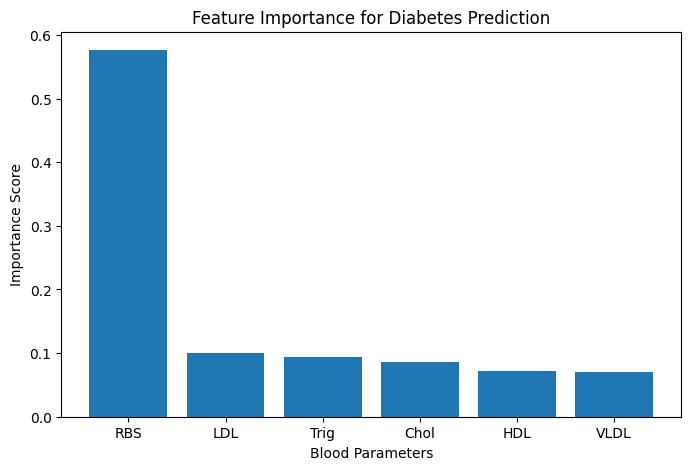

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Blood Parameters")
plt.ylabel("Importance Score")
plt.title("Feature Importance for Diabetes Prediction")

plt.show()

In [99]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values in training data:", np.isnan(X_train_imputed).sum())
print("Missing values in testing data:", np.isnan(X_test_imputed).sum())

Missing values in training data: 0
Missing values in testing data: 0


## Model Comparison

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


def evaluate_models(models, X_train, X_test, y_train, y_test):

    results = []

    for model_name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        results.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        })

    return pd.DataFrame(results).sort_values(
        by="F1 Score",
        ascending=False
    )


model_results = evaluate_models(
    models,
    X_train_imputed,
    X_test_imputed,
    y_train,
    y_test
)

model_results

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.962406,0.947368,0.818182,0.878049
3,Gradient Boosting,0.954887,0.863636,0.863636,0.863636
0,Logistic Regression,0.939850,0.750000,0.954545,0.840000
1,Decision Tree,0.894737,0.681818,0.681818,0.681818


# Best model selection


Based on the model comparison, Random Forest achieved the highest F1-score and overall accuracy. Therefore, it is selected as the final model for diabetes classification.

In [101]:
best_model = models["Random Forest"]

best_model.fit(X_train_imputed, y_train)

best_pred = best_model.predict(X_test_imputed)

print(
    classification_report(
        y_test,
        best_pred,
        target_names=["Non-Diabetic", "Diabetic"]
    )
)

              precision    recall  f1-score   support

Non-Diabetic       0.96      0.99      0.98       111
    Diabetic       0.95      0.82      0.88        22

    accuracy                           0.96       133
   macro avg       0.96      0.90      0.93       133
weighted avg       0.96      0.96      0.96       133



## Cross-Validation

Stratified 5-fold cross-validation is used to evaluate the stability and generalization performance of the selected Random Forest model. F1-score is used as the evaluation metric because the dataset contains class imbalance.

In [102]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("F1 Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

F1 Scores: [0.63414634 0.73684211 0.73684211 0.63157895 0.75555556]
Mean F1 Score: 0.6989930109827414
Standard Deviation: 0.054431931520003425


## Cross-Validation Model Comparison

Stratified 5-fold cross-validation is performed on all candidate models. F1-score is used to compare the models and identify the classifier that provides the most consistent performance across different subsets of the dataset.

In [103]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

cv_results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": model_name,
        "Mean F1 Score": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_results = pd.DataFrame(cv_results).sort_values(
    by="Mean F1 Score",
    ascending=False
)

cv_results

,Model,Mean F1 Score,Standard Deviation
0,Logistic Regression,0.731030,0.081878
3,Gradient Boosting,0.715617,0.074124
2,Random Forest,0.698993,0.054432
1,Decision Tree,0.597402,0.092950


## Logistic Regression with Feature Scaling

Standardization is applied to the input features before Logistic Regression. Feature scaling ensures that blood parameters with different numerical ranges are transformed to a comparable scale. The complete preprocessing and classification workflow is evaluated using stratified 5-fold cross-validation.


In [104]:
from sklearn.preprocessing import StandardScaler

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("F1 Scores:", lr_cv_scores)
print("Mean F1 Score:", lr_cv_scores.mean())
print("Standard Deviation:", lr_cv_scores.std())

F1 Scores: [0.64       0.79166667 0.84444444 0.63829787 0.74074074]
Mean F1 Score: 0.7310299448384555
Standard Deviation: 0.08187752858883406


## Hyperparameter Tuning

Grid Search with stratified 5-fold cross-validation is used to identify the optimal Logistic Regression hyperparameters. F1-score is used as the scoring metric to account for class imbalance.

In [105]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best Parameters: {'model__C': 0.01, 'model__solver': 'lbfgs'}
Best Cross-Validation F1 Score: 0.7497416413373859


## Final Tuned Model Evaluation

In [106]:
final_model = grid_search.best_estimator_

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=["Non-Diabetic", "Diabetic"]
    )
)

              precision    recall  f1-score   support

Non-Diabetic       0.99      0.95      0.97       111
    Diabetic       0.78      0.95      0.86        22

    accuracy                           0.95       133
   macro avg       0.88      0.95      0.91       133
weighted avg       0.96      0.95      0.95       133



## Final Model Selection

The tuned Logistic Regression model was selected as the final diabetes classification model. Although Random Forest achieved a slightly higher F1-score on the held-out test set, Logistic Regression demonstrated better cross-validation performance and higher recall for diabetic patients. The final model achieved 95% recall for the diabetic class, reducing the number of missed diabetic cases.

In [107]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(y_test, final_pred)

print(final_cm)

[[105   6]
 [  1  21]]


In [111]:
import joblib

joblib.dump(
    final_model,
    "Diabetes_model.pkl"
)

print("Diabetes model saved successfully.")

Diabetes model saved successfully.


In [113]:
import joblib
import pandas as pd

loaded_model = joblib.load("Diabetes_model.pkl")

sample_data = pd.DataFrame(
    [[180, 150, 40, 110, 30, 170]],
    columns=["Chol", "Trig", "HDL", "LDL", "VLDL", "RBS"]
)

prediction = loaded_model.predict(sample_data)

if prediction[0] == 1:
    print("Prediction: Diabetic")
else:
    print("Prediction: Non-Diabetic")

Prediction: Diabetic
